In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_theme()

In [30]:
data = {
    "Jahr": [2011, 2011, 2012, 2016, 2017, 2019, 2020, 2020, 2021, 2021, 2021, 2021, 2021, 2022, 2022, 2022, 2023, 2023, 2023, 2023, 2023],
    "Modell": ["ERGO", "EliXR", "EliXR-TIME", "Valx", "ElilE", "Criteria2Query (C2Q)", "Clinical Trial Parser", "Ensemble Modell", "ERNI", "MIMO", "RoBERTa", "CT-BERT", "ecBERT", "PubMedBERT", "SciBERT", "C2Q 2.0", "ClinicalTrialBERT", "Expert System", "C2Q 3.0", "AutoCriteria", "LeafAI"],
    "Typ": ["Regelbasierte Parser", "Regelbasierte Parser", "Regelbasierte Parser", "Regelbasierte Parser", "Regelbasierte Parser", "Regelbasierte Parser, ML", "Regelbasierte Parser, ML", "BERT", "ML, BERT", "BERT", "BERT", "BERT", "BERT", "BERT", "BERT", "Regelbasierte Parser, ML", "BERT", "GPT", "ML, GPT", "GPT", "BERT"],
    "Datensatz": ["Manueller Datensatz", "Manueller Datensatz", "Manueller Datensatz", "Manueller Datensatz", "ElilE", "C2Q Datensatz", "FRD", "Manueller Datensatz", "Manueller Datensatz", "Manueller Datensatz", "Chia, FRD", "FRD", "Chia", "EliIE, Covance, Chia", "LCT", "COVIC", "PROTECTOR1", "Manueller Datensatz", "Manueller Datensatz", "Manueller Datensatz", "LLF"]
}

In [31]:
farben = {"Regelbasierte Parser": "blue", "ML": "green", "BERT": "orange", "GPT": "purple"}
markierungen = {
    "Manueller Datensatz": "MAN",
    "ElilE": "ElilE",
    "C2Q Datensatz": "C2Q Datensatz",
    "FRD": "FRD",
    "Chia": "Chia",
    "LCT Corpus": "LCT",
    "COVIC": "COVIC",
    "PROTECTOR1": "P1",
    "LLF Corpus": "LLF",
}
verfügbare_datasets = ["Chia", "FRD", "LCT", "LLF"]

In [32]:
df = pd.DataFrame(data)

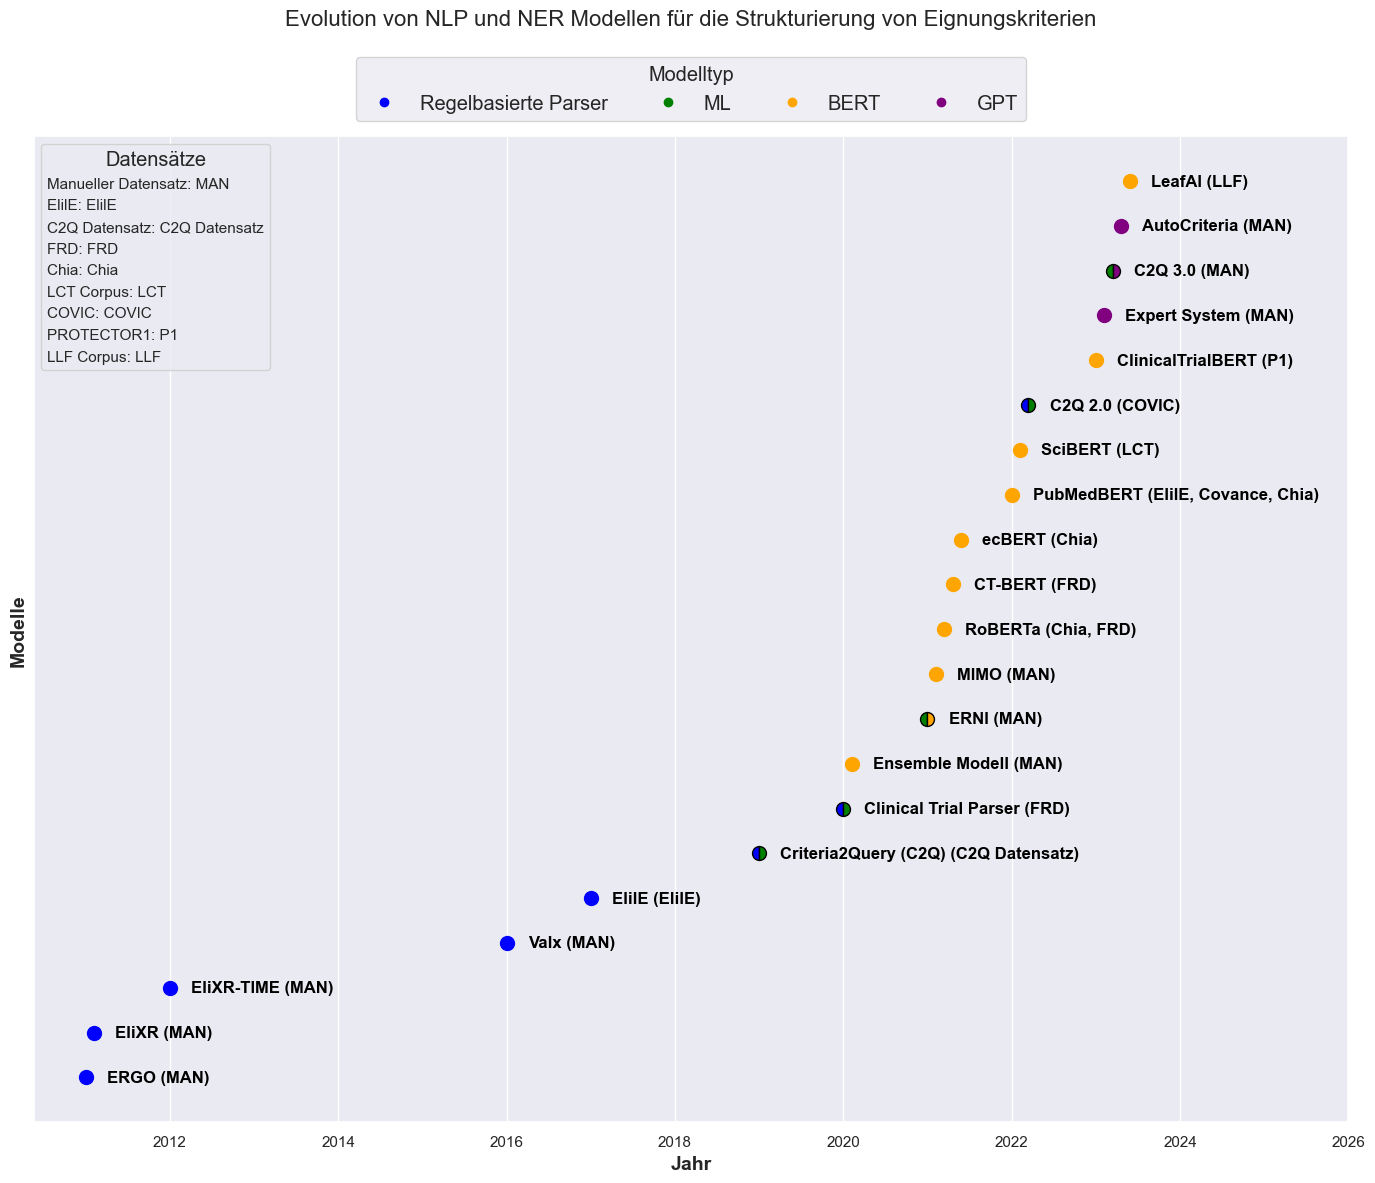

In [33]:
verschiebungen = df.groupby('Jahr').cumcount() * 0.1
plt.figure(figsize=(14, 12))

for (index, row), verschiebung in zip(df.iterrows(), verschiebungen):
    x_wert = row["Jahr"] + verschiebung
    dataset_list = row["Datensatz"].split(", ")
    dataset_text = ", ".join([f"{markierungen.get(d.strip(), d.strip())}" for d in dataset_list])
    plt.text(x_wert + 0.25, index, f"{row['Modell']} ({dataset_text})", verticalalignment='center', horizontalalignment='left', fontsize=12, color='black', weight='bold')
    typ_details = row["Typ"].split(", ")
    if len(typ_details) > 1:
        plt.plot(x_wert, index, marker='o', markersize=10, markerfacecolor=farben[typ_details[0]],
                 markerfacecoloralt=farben[typ_details[1]], markeredgewidth=1, markeredgecolor='black',
                 fillstyle='left', linestyle='None')
    else:
        plt.scatter(x_wert, index, color=farben.get(row["Typ"], "white"), marker='o', s=100)


plt.xlabel("Jahr", fontsize=14, weight='bold')
plt.ylabel("Modelle", fontsize=14, weight='bold')
plt.yticks([])
plt.title("Evolution von NLP und NER Modellen für die Strukturierung von Eignungskriterien", fontsize=16, pad=80)
plt.grid(True)
plt.xlim(right=2026)
typ_legend = [plt.Line2D([0], [0], color=color, marker='o', linestyle='', label=typ) for typ, color in farben.items()]
leg1 = plt.legend(handles=typ_legend, title="Modelltyp", loc='upper center', bbox_to_anchor=(0.5, 1.09), ncol=5, fontsize='large', title_fontsize='large')
dataset_legend = [plt.Line2D([0], [0], label=f"{key}: {value}") for key, value in markierungen.items()]
plt.gca().add_artist(leg1)
plt.legend(handles=dataset_legend, title="Datensätze", loc='upper left', title_fontsize='large', handlelength=0, handletextpad=0)

plt.tight_layout()
plt.savefig("./pics/evolution_modelle.png")
plt.savefig("./pics/evolution_modelle.svg", format='svg')
plt.show()